# Análise exploratória da ação (PETR4)

O notebook lê `equity_daily` no snapshot `data/gas_flare.sqlite`. O ticker padrão é **PETR4**. O recorte usa a âncora do PPI (`MIN(ppi_daily.report_date)`).

O início nativo neste snapshot é **2022-02-01**. Janeiro de 2022 fica sem barras de PETR4 no índice do PPI.

Colunas usadas: `price_open` / `price_max` / `price_min` / `price_med` / `price_last`, `total_quantity`, `vol_hist` / `vol_hist_021` / `vol_hist_126` / `vol_hist_252`.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url, table_exists

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL


'sqlite:///D:\\Users\\Ricardo\\Documents\\opencode\\proj_IV\\data\\gas_flare.sqlite'

In [2]:
TABLE = 'equity_daily'
TICKER = 'PETR4'

def read_table(engine, sql):
    try:
        return pd.read_sql_query(sql, engine)
    except Exception as exc:
        print(f'Skipping query ({exc})')
        return pd.DataFrame()

if not table_exists(ENGINE, TABLE):
    print(f'Missing table: {TABLE} in data/gas_flare.sqlite')
    eq = pd.DataFrame()
else:
    eq = read_table(
        ENGINE,
        f"""
        SELECT tradedate, ticker,
               price_open, price_max, price_min, price_med, price_last,
               total_quantity, total_transactions, total_cash,
               vol_hist, vol_hist_021, vol_hist_126, vol_hist_252,
               source_db, ingested_at
        FROM {TABLE}
        WHERE ticker = '{TICKER}'
        ORDER BY tradedate
        """,
    )

ppi_anchor = pd.to_datetime(
    pd.read_sql_query('SELECT MIN(report_date) AS d FROM ppi_daily', ENGINE).iloc[0, 0]
)
print(f'PPI anchor: {ppi_anchor.date()}')

price_cols = ['price_open', 'price_max', 'price_min', 'price_med', 'price_last']
vol_cols = ['vol_hist', 'vol_hist_021', 'vol_hist_126', 'vol_hist_252']

if eq.empty:
    print(f'{TABLE} has no {TICKER} rows.')
else:
    eq['tradedate'] = pd.to_datetime(eq['tradedate'], errors='coerce')
    for col in price_cols + vol_cols + ['total_quantity', 'total_transactions', 'total_cash']:
        if col in eq.columns:
            eq[col] = pd.to_numeric(eq[col], errors='coerce')
    eq = eq[eq['tradedate'] >= ppi_anchor].copy()
    print(f'Rows: {len(eq):,}  ticker={TICKER}')
    print(f"Date range: {eq['tradedate'].min().date()} to {eq['tradedate'].max().date()}")

eq.head()


PPI anchor: 2022-01-05
Rows: 1,156  ticker=PETR4
Date range: 2022-02-01 to 2026-09-18


,tradedate,ticker,price_open,price_max,price_min,price_med,price_last,total_quantity,total_transactions,total_cash,vol_hist,vol_hist_021,vol_hist_126,vol_hist_252,source_db,ingested_at
0,2022-02-01,PETR4,32.35,33.32,31.95,32.83,33.00,57315200,92039,1.882094e+09,0.453430,0.312568,0.372132,0.453430,dadodb_dev,2026-08-18 19:56:02.389215
1,2022-02-02,PETR4,33.41,33.49,32.36,32.64,32.52,36271700,80693,1.184107e+09,0.453500,0.315406,0.371728,0.453500,dadodb_dev,2026-08-18 19:56:02.389215
2,2022-02-03,PETR4,32.35,32.92,31.62,32.03,32.07,51087800,92360,1.636398e+09,0.451970,0.321611,0.371766,0.451970,dadodb_dev,2026-08-18 19:56:02.389215
3,2022-02-04,PETR4,32.41,33.23,31.88,32.78,32.63,59346800,94572,1.945650e+09,0.451260,0.286011,0.371007,0.451260,dadodb_dev,2026-08-18 19:56:02.389215
4,2022-02-07,PETR4,32.55,32.78,32.13,32.36,32.15,48868100,76874,1.581855e+09,0.449777,0.293973,0.356484,0.449777,dadodb_dev,2026-08-18 19:56:02.389215


In [3]:
if eq.empty:
    print('No equity rows to summarise.')
else:
    petr = eq.set_index('tradedate').sort_index()
    bdays = pd.bdate_range(petr.index.min(), petr.index.max())
    missing = bdays.difference(petr.index)
    print(f'Business days in span: {len(bdays)}')
    print(f'Trading bars: {len(petr)}')
    print(f'Business days with no bar: {len(missing)} (holidays / unscheduled gaps)')
    coverage = pd.DataFrame({
        'column': price_cols + ['total_quantity'] + vol_cols,
        'nulls': [int(petr[c].isna().sum()) if c in petr.columns else None for c in price_cols + ['total_quantity'] + vol_cols],
        'last': [petr[c].dropna().iloc[-1] if c in petr.columns and petr[c].notna().any() else None for c in price_cols + ['total_quantity'] + vol_cols],
    })
    display(coverage)
    display(petr[price_cols + ['total_quantity']].tail(10))


Business days in span: 1209
Trading bars: 1156
Business days with no bar: 53 (holidays / unscheduled gaps)


,column,nulls,last
0,price_open,0,4.840000e+01
1,price_max,0,4.883000e+01
2,price_min,0,4.825000e+01
3,price_med,0,4.850000e+01
4,price_last,0,4.850000e+01
5,total_quantity,0,5.266470e+07
6,vol_hist,0,2.717323e-01
7,vol_hist_021,0,3.629473e-01
8,vol_hist_126,0,3.038484e-01
9,vol_hist_252,0,2.717323e-01


,price_open,price_max,price_min,price_med,price_last,total_quantity
tradedate,,,,,,
2026-09-04,47.32,47.45,46.72,47.10,47.11,29125700
2026-09-08,48.10,48.50,47.53,48.06,48.09,34388500
2026-09-09,48.74,48.95,48.19,48.51,48.42,40391600
2026-09-10,48.91,49.60,48.54,49.11,49.12,43955800
2026-09-11,48.50,49.12,48.09,48.67,49.00,27608600
2026-09-14,49.51,49.73,48.61,49.19,48.92,32098300
2026-09-15,49.06,50.70,49.03,50.21,50.43,46559600
2026-09-16,49.94,49.98,48.62,49.00,48.65,52457100
2026-09-17,48.03,49.20,47.96,48.55,48.61,32429800


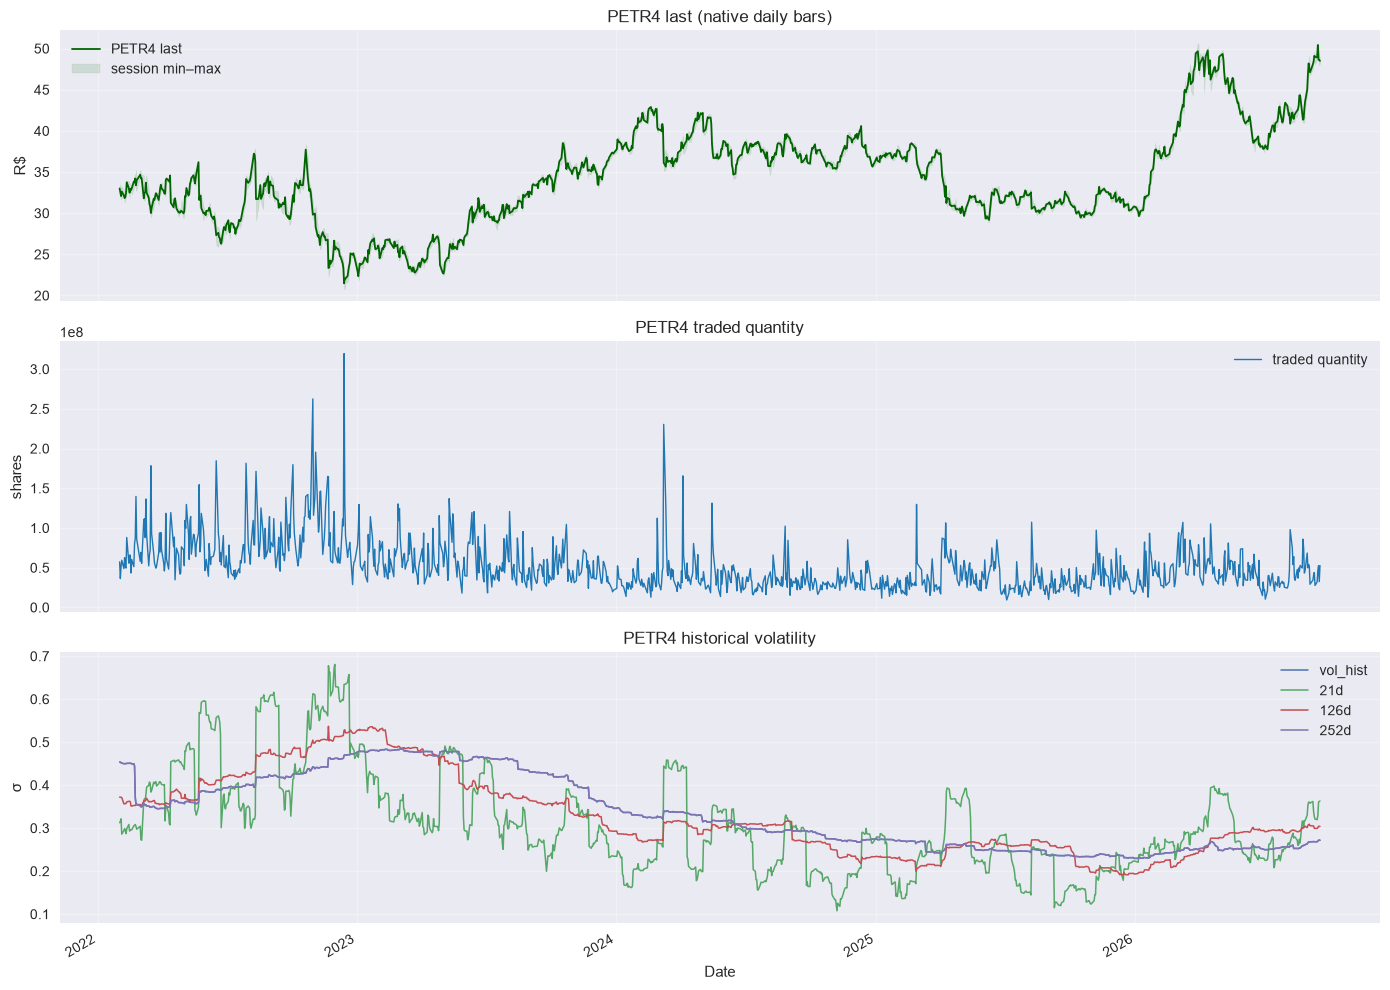

In [4]:
if eq.empty:
    print('No equity rows to plot.')
else:
    petr = eq.set_index('tradedate').sort_index()
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    ax.plot(petr.index, petr['price_last'], linewidth=1.3, color='darkgreen', label='PETR4 last')
    if petr['price_max'].notna().any() and petr['price_min'].notna().any():
        ax.fill_between(petr.index, petr['price_min'], petr['price_max'], color='darkgreen', alpha=0.12, label='session min–max')
    ax.set_ylabel('R$')
    ax.set_title('PETR4 last (native daily bars)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1]
    ax.plot(petr.index, petr['total_quantity'], linewidth=1.0, color='#1f77b4', label='traded quantity')
    ax.set_ylabel('shares')
    ax.set_title('PETR4 traded quantity')
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[2]
    for col, label in [
        ('vol_hist', 'vol_hist'),
        ('vol_hist_021', '21d'),
        ('vol_hist_126', '126d'),
        ('vol_hist_252', '252d'),
    ]:
        if col in petr.columns and petr[col].notna().any():
            ax.plot(petr.index, petr[col], linewidth=1.1, label=label)
    ax.set_ylabel('σ')
    ax.set_xlabel('Date')
    ax.set_title('PETR4 historical volatility')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()


In [5]:
if eq.empty:
    print('No equity rows to describe.')
else:
    petr = eq.set_index('tradedate').sort_index()
    display(petr[price_cols + ['total_quantity'] + [c for c in vol_cols if c in petr.columns]].describe().T.round(4))
    daily_ret = petr['price_last'].pct_change() * 100
    print(f'Daily last-to-last return %  mean={daily_ret.mean():.3f}  std={daily_ret.std():.3f}  n={daily_ret.dropna().shape[0]}')


,count,mean,std,min,25%,50%,75%,max
price_open,1156.0,3.426880e+01,5.702000e+00,2.100000e+01,3.058750e+01,3.390500e+01,3.781250e+01,5.007000e+01
price_max,1156.0,3.469740e+01,5.733100e+00,2.211000e+01,3.096000e+01,3.430500e+01,3.821000e+01,5.070000e+01
price_min,1156.0,3.385400e+01,5.688200e+00,2.077000e+01,3.020000e+01,3.326000e+01,3.743000e+01,4.949000e+01
price_med,1156.0,3.427230e+01,5.711300e+00,2.154000e+01,3.055250e+01,3.378500e+01,3.777250e+01,5.021000e+01
price_last,1156.0,3.428240e+01,5.715800e+00,2.147000e+01,3.059750e+01,3.383000e+01,3.778500e+01,5.043000e+01
total_quantity,1156.0,5.151336e+07,3.074578e+07,9.354700e+06,3.028895e+07,4.382785e+07,6.358610e+07,3.195016e+08
vol_hist,1156.0,3.350000e-01,8.560000e-02,2.296000e-01,2.530000e-01,3.165000e-01,4.193000e-01,4.853000e-01
vol_hist_021,1156.0,3.104000e-01,1.175000e-01,1.077000e-01,2.273000e-01,2.894000e-01,3.747000e-01,6.808000e-01
vol_hist_126,1156.0,3.275000e-01,9.280000e-02,1.914000e-01,2.595000e-01,3.031000e-01,3.820000e-01,5.368000e-01
vol_hist_252,1156.0,3.350000e-01,8.560000e-02,2.296000e-01,2.530000e-01,3.165000e-01,4.193000e-01,4.853000e-01


Daily last-to-last return %  mean=0.056  std=2.106  n=1155
